# Emissions de CO2 par habitant - Analyse par pays

Jeu de donnees : `join_CO2_geography.csv`, emissions de CO2 par habitant
croisees avec une table de reference geographique (regroupements regionaux,
classe de revenu Banque mondiale, coordonnees).

Le fichier d'origine est un export abime : il est tabule, les decimales
utilisent la virgule, et surtout l'encodage change en cours de fichier
(les premieres lignes sont en ASCII, la suite en UTF-16LE). La premiere
cellule de code reconstruit le fichier proprement avant toute analyse.

Plan du notebook :

1. Chargement et reparation du fichier
2. Inspection et qualite des donnees
3. Analyse univariee
4. Evolution dans le temps
5. Comparaison par groupe de revenu et par region
6. Les plus gros emetteurs
7. Repartition geographique
8. Export du fichier propre

In [1]:
import io

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

## 1. Chargement et reparation du fichier

`charger()` lit le fichier en binaire, decoupe au premier octet nul (le point
ou l'encodage bascule), decode chaque moitie avec le bon codec puis assemble
le tout. Sans cette etape, pandas ne recupere que les 199 premieres lignes.

In [2]:
FICHIER = "join_CO2_geography.csv"


def charger(chemin=FICHIER):
    """Lit l'export a double encodage et renvoie un DataFrame propre."""
    brut = open(chemin, "rb").read()

    coupure = brut.find(b"\x00")
    if coupure == -1:                       # fichier deja homogene
        texte = brut.decode("utf-8", errors="ignore")
    else:
        debut = brut[:coupure].decode("utf-8", errors="ignore").rstrip("\n")
        fin = brut[coupure - 1:].decode("utf-16-le", errors="ignore")
        texte = debut + fin

    df = pd.read_csv(io.StringIO(texte), sep="\t", decimal=",")

    # la derniere colonne traine des virgules de fin de ligne
    df.columns = [c.strip().strip(",") for c in df.columns]
    df["Longitude"] = pd.to_numeric(
        df["Longitude"].astype(str).str.rstrip(",").str.replace(",", ".", regex=False),
        errors="coerce")

    df = df.dropna(subset=["country", "Annee"])
    df["Annee"] = df["Annee"].astype(int)
    return df


df = charger()
print("Dimensions :", df.shape)
print("Pays :", df["country"].nunique())
print("Periode :", df["Annee"].min(), "-", df["Annee"].max())
df.head()

Dimensions : (10505, 13)
Pays : 191
Periode : 1960 - 2014


,Annee,country,Eight Regions,Four Regions,Geo,Members Oecd G77,Six Regions,UN member since,World bank income group 2017,World bank region,CO2 par habitant,Latitude,Longitude
0,1960,Afghanistan,asia_west,asia,afg,g77,south_asia,19/11/1946,Low income,South Asia,0.0461,33.0,66.0
1,1961,Afghanistan,asia_west,asia,afg,g77,south_asia,19/11/1946,Low income,South Asia,0.0536,33.0,66.0
2,1962,Afghanistan,asia_west,asia,afg,g77,south_asia,19/11/1946,Low income,South Asia,0.0738,33.0,66.0
3,1963,Afghanistan,asia_west,asia,afg,g77,south_asia,19/11/1946,Low income,South Asia,0.0742,33.0,66.0
4,1964,Afghanistan,asia_west,asia,afg,g77,south_asia,19/11/1946,Low income,South Asia,0.0863,33.0,66.0


## 2. Inspection et qualite des donnees

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10505 entries, 0 to 10504
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Annee                         10505 non-null  int64  
 1   country                       10505 non-null  object 
 2   Eight Regions                 10395 non-null  object 
 3   Four Regions                  10395 non-null  object 
 4   Geo                           10395 non-null  object 
 5   Members Oecd G77              10340 non-null  object 
 6   Six Regions                   10395 non-null  object 
 7   UN member since               10340 non-null  object 
 8   World bank income group 2017  10395 non-null  object 
 9   World bank region             10395 non-null  object 
 10  CO2 par habitant              9188 non-null   float64
 11  Latitude                      10395 non-null  float64
 12  Longitude                     10395 non-null  float64
dtypes: flo

In [4]:
manquantes = pd.DataFrame({
    "manquantes": df.isna().sum(),
    "part (%)": (df.isna().mean() * 100).round(1),
})
manquantes.sort_values("manquantes", ascending=False)

,manquantes,part (%)
CO2 par habitant,1317,12.5
Members Oecd G77,165,1.6
UN member since,165,1.6
Geo,110,1.0
Eight Regions,110,1.0
World bank income group 2017,110,1.0
World bank region,110,1.0
Four Regions,110,1.0
Six Regions,110,1.0
Latitude,110,1.0


In [5]:
# La seule mesure du jeu de donnees est CO2 par habitant. Les lignes sans
# mesure ne servent a rien pour l'analyse, on les met de cote.
co2 = df.dropna(subset=["CO2 par habitant"]).copy()
print("Lignes exploitables :", len(co2), "sur", len(df))
co2["CO2 par habitant"].describe()

Lignes exploitables : 9188 sur 10505


count    9188.000000
mean        4.228553
std         7.522606
min        -0.020100
25%         0.332000
50%         1.390000
75%         5.710000
max       101.000000
Name: CO2 par habitant, dtype: float64

## 3. Analyse univariee

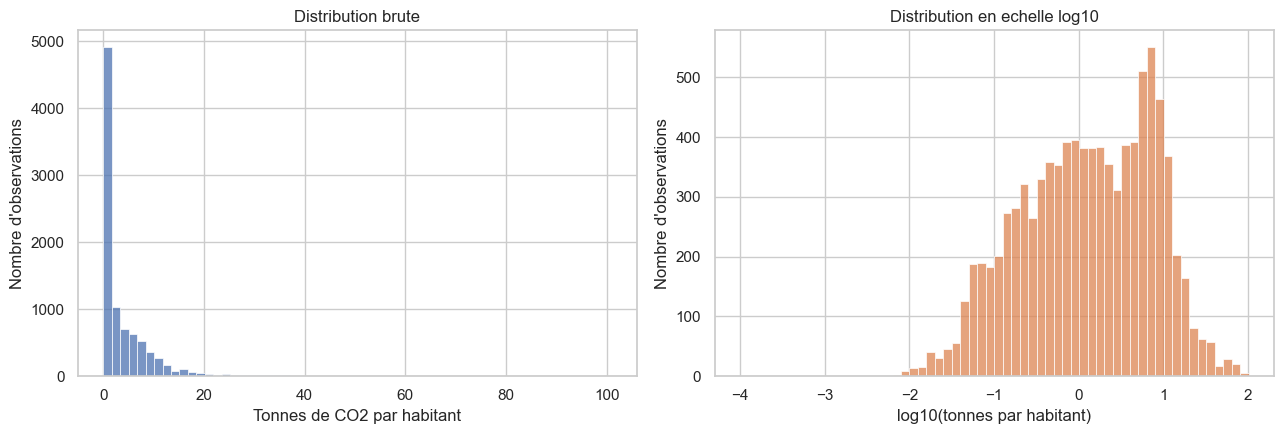

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(co2["CO2 par habitant"], bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution brute")
axes[0].set_xlabel("Tonnes de CO2 par habitant")

sns.histplot(np.log10(co2["CO2 par habitant"].clip(lower=1e-4)),
             bins=60, ax=axes[1], color="#DD8452")
axes[1].set_title("Distribution en echelle log10")
axes[1].set_xlabel("log10(tonnes par habitant)")

for ax in axes:
    ax.set_ylabel("Nombre d'observations")

plt.tight_layout()
plt.show()

In [7]:
# La distribution est tres asymetrique : quelques pays tirent la moyenne
# vers le haut. La mediane est donc plus representative que la moyenne.
print("Moyenne :", round(co2["CO2 par habitant"].mean(), 2))
print("Mediane :", round(co2["CO2 par habitant"].median(), 2))
print("Ecart-type :", round(co2["CO2 par habitant"].std(), 2))
print("Maximum :", round(co2["CO2 par habitant"].max(), 2))

Moyenne : 4.23
Mediane : 1.39
Ecart-type : 7.52
Maximum : 101.0


## 4. Evolution dans le temps

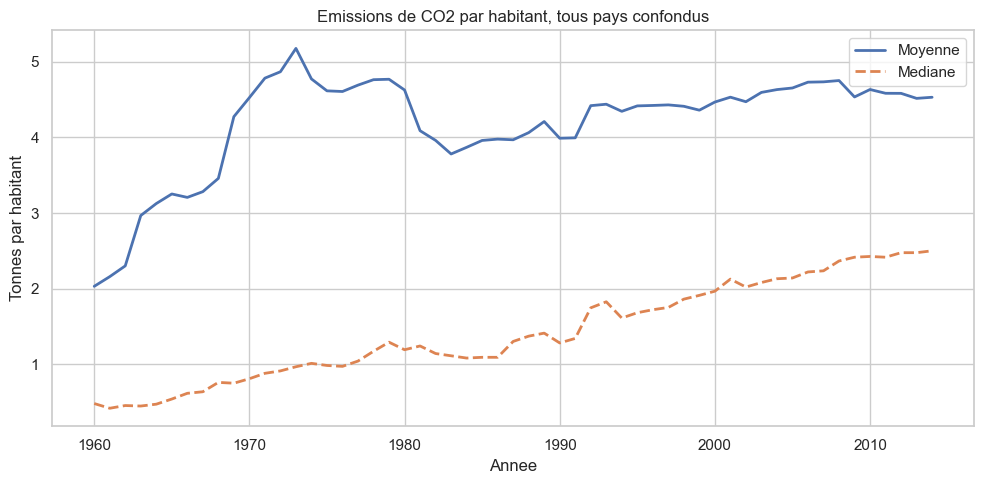

,mean,median,count
Annee,,,
2010,4.635281,2.425,190
2011,4.585115,2.415,190
2012,4.584218,2.475,190
2013,4.517789,2.475,190
2014,4.532507,2.500,188


In [8]:
par_annee = co2.groupby("Annee")["CO2 par habitant"].agg(["mean", "median", "count"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(par_annee.index, par_annee["mean"], label="Moyenne", linewidth=2)
ax.plot(par_annee.index, par_annee["median"], label="Mediane", linewidth=2,
        linestyle="--")
ax.set_title("Emissions de CO2 par habitant, tous pays confondus")
ax.set_xlabel("Annee")
ax.set_ylabel("Tonnes par habitant")
ax.legend()
plt.tight_layout()
plt.show()

par_annee.tail()

## 5. Comparaison par groupe de revenu et par region

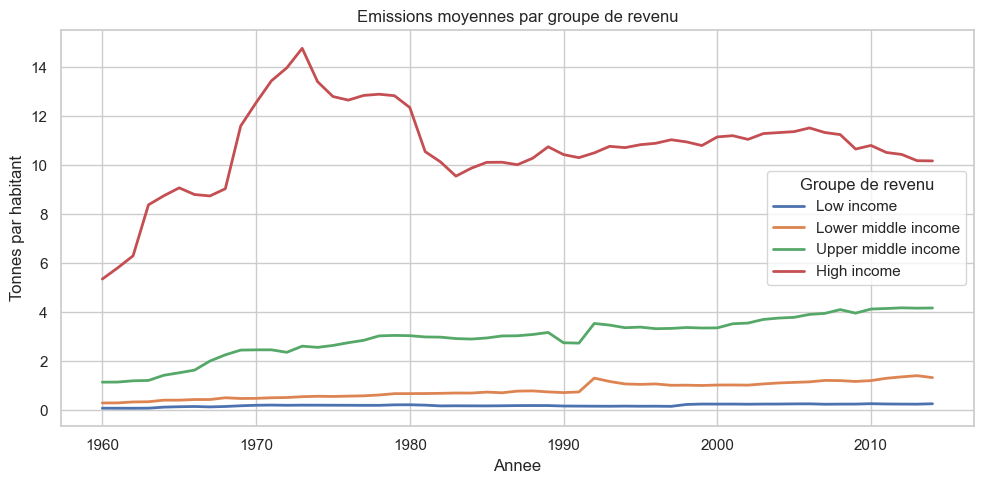

In [9]:
ordre_revenu = ["Low income", "Lower middle income",
                "Upper middle income", "High income"]
revenu = (co2[co2["World bank income group 2017"].isin(ordre_revenu)]
          .groupby(["Annee", "World bank income group 2017"])["CO2 par habitant"]
          .mean().reset_index())

plt.figure(figsize=(10, 5))
sns.lineplot(data=revenu, x="Annee", y="CO2 par habitant",
             hue="World bank income group 2017", hue_order=ordre_revenu,
             linewidth=2)
plt.title("Emissions moyennes par groupe de revenu")
plt.xlabel("Annee")
plt.ylabel("Tonnes par habitant")
plt.legend(title="Groupe de revenu")
plt.tight_layout()
plt.show()

              count  mean  median
Four Regions                     
europe         1796  7.32    6.76
americas       1925  3.53    1.69
asia           2685  6.08    1.35
africa         2736  0.90    0.23


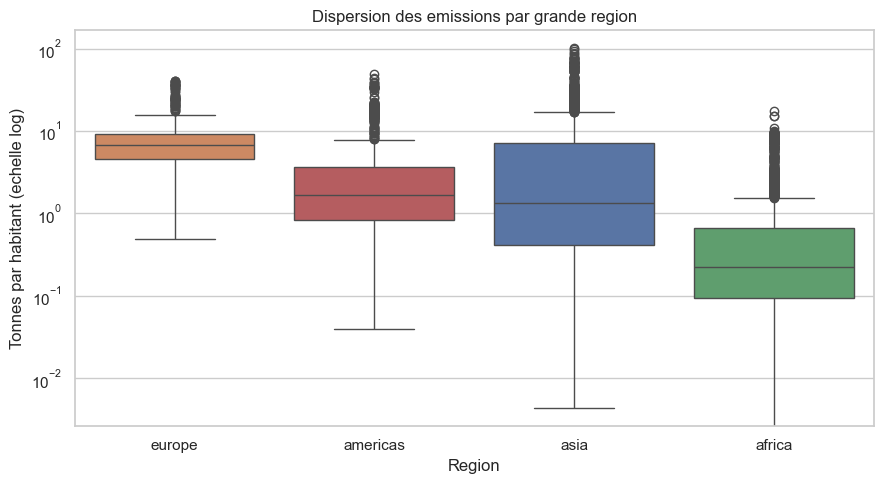

In [10]:
regions = (co2.groupby("Four Regions")["CO2 par habitant"]
           .agg(["count", "mean", "median"]).round(2)
           .sort_values("median", ascending=False))
print(regions)

plt.figure(figsize=(9, 5))
sns.boxplot(data=co2, x="Four Regions", y="CO2 par habitant",
            order=regions.index, hue="Four Regions", palette="deep", legend=False)
plt.yscale("log")
plt.title("Dispersion des emissions par grande region")
plt.xlabel("Region")
plt.ylabel("Tonnes par habitant (echelle log)")
plt.tight_layout()
plt.show()

## 6. Les plus gros emetteurs

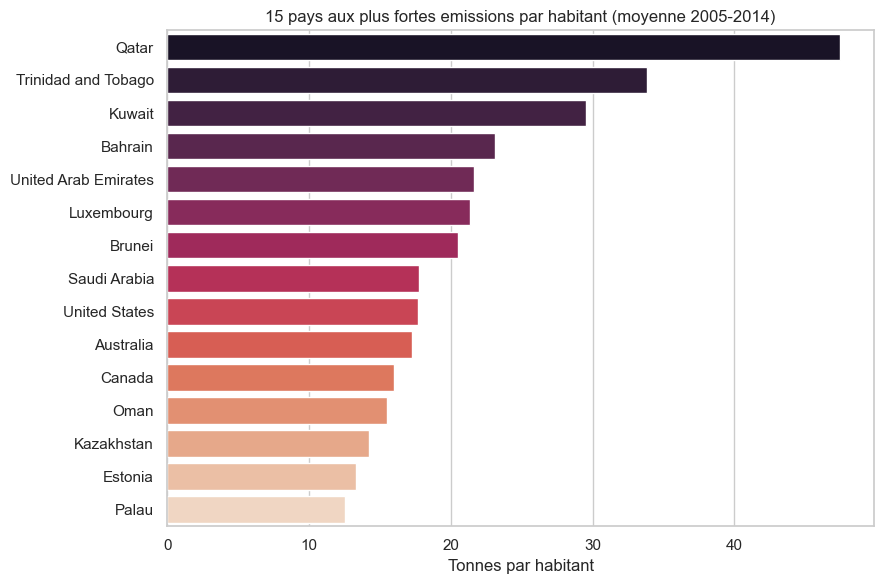

country
Qatar                   47.48
Trinidad and Tobago     33.84
Kuwait                  29.57
Bahrain                 23.13
United Arab Emirates    21.67
Luxembourg              21.38
Brunei                  20.50
Saudi Arabia            17.74
United States           17.71
Australia               17.30
Canada                  15.98
Oman                    15.47
Kazakhstan              14.20
Estonia                 13.32
Palau                   12.53
Name: CO2 par habitant, dtype: float64

In [11]:
recent = co2[co2["Annee"] >= 2005]
top = (recent.groupby("country")["CO2 par habitant"].mean()
       .sort_values(ascending=False).head(15).round(2))

plt.figure(figsize=(9, 6))
sns.barplot(x=top.values, y=top.index, hue=top.index,
            palette="rocket", legend=False)
plt.title("15 pays aux plus fortes emissions par habitant (moyenne 2005-2014)")
plt.xlabel("Tonnes par habitant")
plt.ylabel("")
plt.tight_layout()
plt.show()

top

In [12]:
bas = (recent.groupby("country")["CO2 par habitant"].mean()
       .sort_values().head(15).round(3))
print("Les 15 pays aux plus faibles emissions par habitant (2005-2014)")
bas

Les 15 pays aux plus faibles emissions par habitant (2005-2014)


country
Burundi                     0.027
Congo, Dem. Rep.            0.036
Chad                        0.045
Somalia                     0.051
Central African Republic    0.061
Rwanda                      0.062
Mali                        0.068
Malawi                      0.071
Niger                       0.074
Ethiopia                    0.085
Madagascar                  0.105
Uganda                      0.108
South Sudan                 0.128
Sierra Leone                0.130
Mozambique                  0.131
Name: CO2 par habitant, dtype: float64

## 7. Repartition geographique

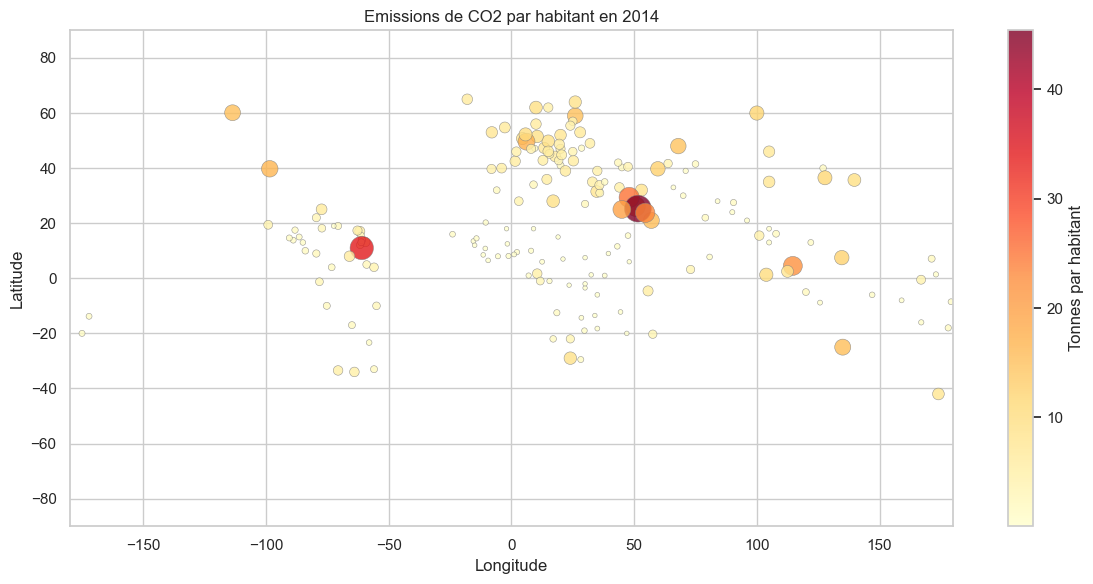

In [13]:
derniere = co2["Annee"].max()
carte = co2[co2["Annee"] == derniere].dropna(subset=["Latitude", "Longitude"])

plt.figure(figsize=(12, 6))
points = plt.scatter(carte["Longitude"], carte["Latitude"],
                     s=carte["CO2 par habitant"] * 8 + 10,
                     c=carte["CO2 par habitant"], cmap="YlOrRd",
                     alpha=0.8, edgecolors="grey", linewidths=0.4)
plt.colorbar(points, label="Tonnes par habitant")
plt.title("Emissions de CO2 par habitant en {}".format(derniere))
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.tight_layout()
plt.show()

## 8. Export du fichier propre

Le fichier repare est enregistre en UTF-8, separe par des virgules et avec le
point comme separateur decimal. Il peut ensuite etre ouvert directement dans
pandas, Excel ou Tableau.

In [14]:
propre = co2.copy()
propre.to_csv("co2_par_habitant_propre.csv", index=False, encoding="utf-8")
print("Ecrit : co2_par_habitant_propre.csv")
print(propre.shape)
propre.head()

Ecrit : co2_par_habitant_propre.csv
(9188, 13)


,Annee,country,Eight Regions,Four Regions,Geo,Members Oecd G77,Six Regions,UN member since,World bank income group 2017,World bank region,CO2 par habitant,Latitude,Longitude
0,1960,Afghanistan,asia_west,asia,afg,g77,south_asia,19/11/1946,Low income,South Asia,0.0461,33.0,66.0
1,1961,Afghanistan,asia_west,asia,afg,g77,south_asia,19/11/1946,Low income,South Asia,0.0536,33.0,66.0
2,1962,Afghanistan,asia_west,asia,afg,g77,south_asia,19/11/1946,Low income,South Asia,0.0738,33.0,66.0
3,1963,Afghanistan,asia_west,asia,afg,g77,south_asia,19/11/1946,Low income,South Asia,0.0742,33.0,66.0
4,1964,Afghanistan,asia_west,asia,afg,g77,south_asia,19/11/1946,Low income,South Asia,0.0863,33.0,66.0


## Synthese

- Le fichier d'origine n'est pas lisible tel quel : sans la reparation
  d'encodage, on perd 98 % des lignes sans aucun message d'erreur.
- Une seule variable quantitative reelle, les emissions par habitant, decrite
  par un grand nombre de variables qualitatives geographiques.
- La distribution est fortement asymetrique : la mediane mondiale reste basse
  alors que quelques pays depassent largement les 20 tonnes par habitant.
- Le groupe de revenu separe tres nettement les pays, et l'ecart entre revenus
  eleves et faibles reste large sur toute la periode.
- Les plus gros emetteurs par habitant sont des pays petits et riches en
  hydrocarbures, pas les pays dont les emissions totales sont les plus
  importantes : le rapport par habitant change completement le classement.